<a href="https://colab.research.google.com/github/Safae-s/TP2-ML-MASTER/blob/main/TP2_ML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#Presentation de dataset

In [ ]:
#Importation des bibliotheques

import pandas as pd
import numpy as  np

import matplotlib.pyplot as plt
import seaborn as sns

#charger dataset
from sklearn.datasets import fetch_california_housing

In [ ]:
#Charger dataset:
housing = fetch_california_housing()

#Affichage des noms des colonnes:
print(housing.feature_names)

#affichage de target
print(housing.target)

['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']
[4.526 3.585 3.521 ... 0.923 0.847 0.894]


In [ ]:
#Transformation de Dataset en DataFrame:

#Creation de dataframe:
df = pd.DataFrame(housing.data, columns=housing.feature_names)

#Ajout de colonne target:
df['Price']= housing.target

#Afficher les 5 premiere  et derniere lignes:
print("\n-les 5 premiere:\n",df.head())
print("\n-les 5 derniere: \n",df.tail())

#Dimensions de dataset:
print("\n-Dimensions de dataset:\n",df.shape)

#Types des colonnes:
print("\n-Types des colonnes:\n",df.dtypes)

#Informations generales:
print("\n-Des Infos generale:\n",df.info())



-les 5 premiere:
    MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  Price  
0    -122.23  4.526  
1    -122.22  3.585  
2    -122.24  3.521  
3    -122.25  3.413  
4    -122.25  3.422  

-les 5 derniere: 
        MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
20635  1.5603      25.0  5.045455   1.133333       845.0  2.560606     39.48   
20636  2.5568      18.0  6.114035   1.315789       356.0  3.122807     39.49   
20637  1.7000      17.0  5.205543   1.120092      1007.0  2.325635     39.43   
20638  1.8672      18.0  5.329513   1.171920       7


-Les Valeurs manquantes:
 MedInc        0
HouseAge      0
AveRooms      0
AveBedrms     0
Population    0
AveOccup      0
Latitude      0
Longitude     0
Price         0
dtype: int64

-Statistiques descriptives:
              MedInc      HouseAge      AveRooms     AveBedrms    Population  \
count  20640.000000  20640.000000  20640.000000  20640.000000  20640.000000   
mean       3.870671     28.639486      5.429000      1.096675   1425.476744   
std        1.899822     12.585558      2.474173      0.473911   1132.462122   
min        0.499900      1.000000      0.846154      0.333333      3.000000   
25%        2.563400     18.000000      4.440716      1.006079    787.000000   
50%        3.534800     29.000000      5.229129      1.048780   1166.000000   
75%        4.743250     37.000000      6.052381      1.099526   1725.000000   
max       15.000100     52.000000    141.909091     34.066667  35682.000000   

           AveOccup      Latitude     Longitude         Price  
count  206

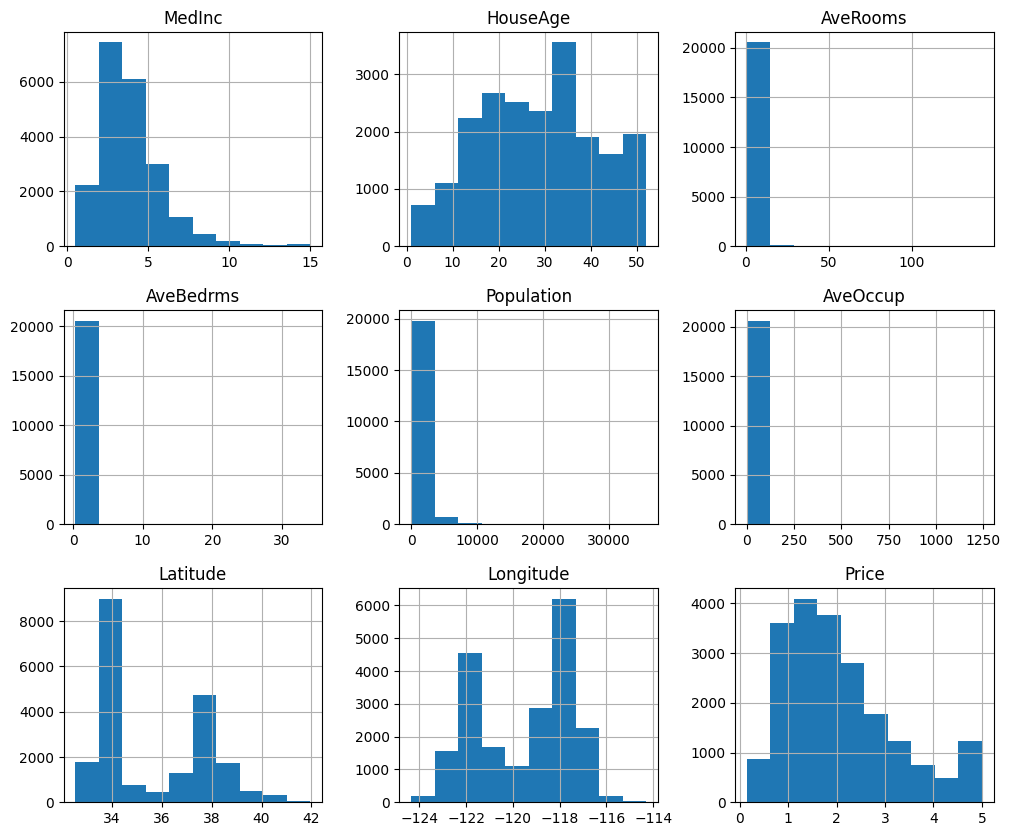

In [ ]:
#Vérification des valeurs manquantes:
print("\n-Les Valeurs manquantes:\n",df.isnull().sum())

#Statistiques descriptives:(min,max,moy,median....)
print("\n-Statistiques descriptives:\n",df.describe())

#Histogrammes:(distrubution des variables)
print("\n-Histogrammes:\n",df.hist(figsize=(12,10)))
plt.show()

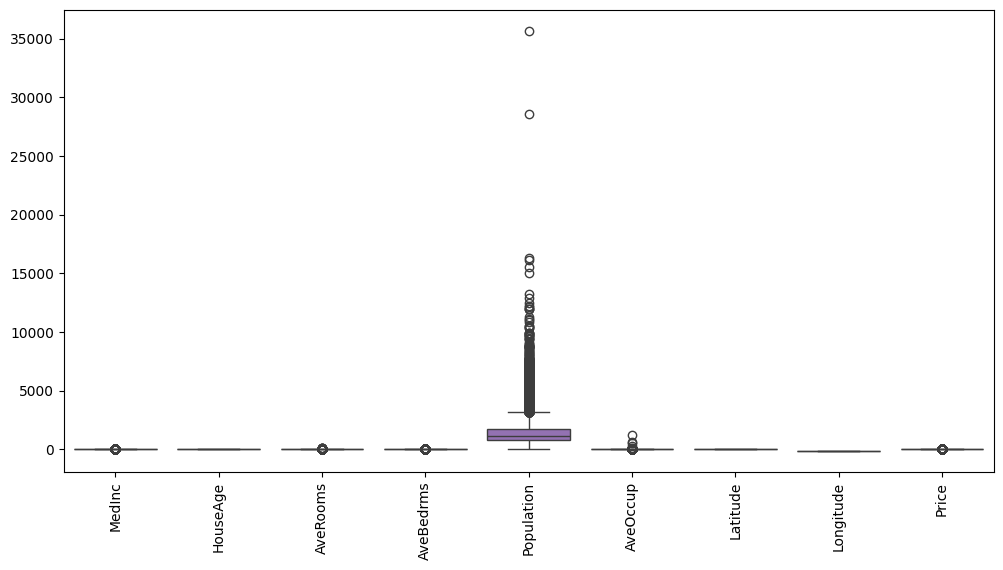

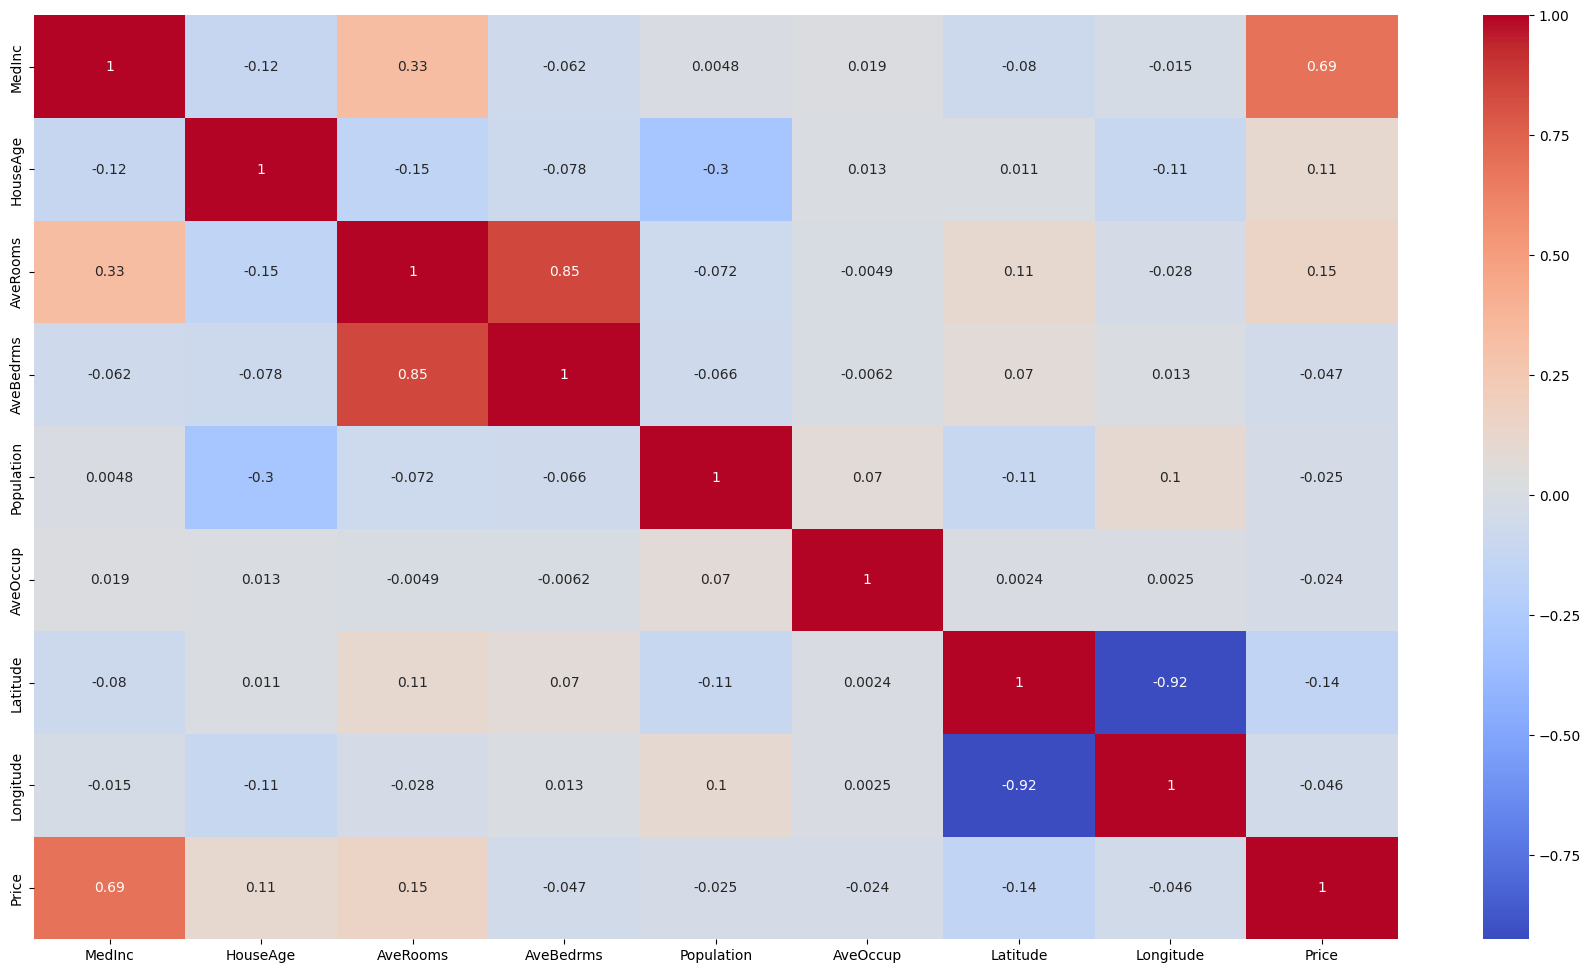


-Observation Finale-Price-:
 count    20640.000000
mean         2.068558
std          1.153956
min          0.149990
25%          1.196000
50%          1.797000
75%          2.647250
max          5.000010
Name: Price, dtype: float64


In [ ]:
#Detection outliers:
plt.figure(figsize=(12,6))
sns.boxplot(data=df)
plt.xticks(rotation=90)
plt.show()

#Correlation matrix:(La relation entre variable et target)
plt.figure(figsize=(22,12))
sns.heatmap(df.corr(), annot=True , cmap='coolwarm')
plt.show()
#Observation fibnale:
print("\n-Observation Finale-Price-:\n",df['Price'].describe())

In [ ]:
#2-Prétraitement des donnnées:

In [ ]:
#Séparation des variables explicatives et le target:

#Variable explicatives:
X = df.drop("Price", axis=1)

#Variable cible:
y = df["Price"]

#Affichage des dimensions:(X->features, y->target)
print("\n-Les dimensions de Variable explicative:\n", X.shape)
print("\n-Les dimensions de Variable cible:\n", y.shape)



-Les dimensions de Variable explicative:
 (20640, 8)

-Les dimensions de Variable cible:
 (20640,)


In [ ]:
#Vérification des outliers avec méthode IQR:

#calcule de Q1:
Q1 = X.quantile(0.25)

#Calcule Q3:
Q3 = X.quantile(0.75)

#calcule IQR
IQR = Q3 - Q1

#Filtrer les valeurs normales:
X_clean = X[~((X < (Q1 -1.5 * IQR))).any(axis=1)]
print("\n-Ancienne taille:", X.shape)
print("\n-Nouvelle taille:", X_clean.shape)


-Ancienne taille: (20640, 8)

-Nouvelle taille: (20407, 8)


In [ ]:
#Adapter le target aprés la suppression des outliers
y_clean = y.loc[X_clean.index]
print(y_clean.shape)

(20407,)


In [ ]:
#Division training and Test:

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_clean,y_clean,test_size=0.2,random_state=42
)

print(X_train.shape)
print(X_test.shape)

(16325, 8)
(4082, 8)


In [ ]:
#Standarisation des donnees:
from sklearn.preprocessing import StandardScaler

#creation scaler,
scaler = StandardScaler()
#train
X_train_scaled = scaler.fit_transform(X_train)
#test:
X_test_scaled = scaler.transform(X_test)

print(X_train_scaled[:5])


[[ 0.16809802 -0.20594168 -0.00961839 -0.3109054  -0.01458954 -0.01654714
   0.05878168  0.17492774]
 [ 0.01346966 -1.16109995  0.37170648 -0.03566209 -0.80024085 -0.01627445
   1.59045321 -0.80263679]
 [ 0.62434976 -0.92231038  0.58960479 -0.01661526  1.04989783  0.01446248
  -1.2954401   1.35698282]
 [-0.83409733 -0.84271386 -0.24957635 -0.05975408  0.08274003  0.06035173
   1.61847159 -0.98717703]
 [-1.40331206 -0.84271386 -0.19015969  0.07981043 -1.09047587 -0.03183215
   0.95070016 -0.47844447]]


In [ ]:
#Pour Comparaison---> MinMax Scaling & Standarisation
from sklearn.preprocessing import MinMaxScaler

minmax = MinMaxScaler()

X_train_minmax = minmax.fit_transform(X_train)
X_test_minmax = minmax.transform(X_test)

#Vérification finale:
print("Pretraitement est terminé avec succes")

Pretraitement est terminé avec succes


**Importation des modèles pour utiliser les algorithmes de regression.**


In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor


In [ ]:
#Importation des metriques:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
import numpy as np


**Linear Regression**

In [ ]:
lr = LinearRegression()

#training
lr.fit(X_train_scaled, y_train)

#Prediction
y_pred_lr = lr.predict(X_test_scaled)

#Evaluation
mae_lr = mean_absolute_error(y_test, y_pred_lr)
rmse_lr =np.sqrt(mean_squared_error(y_test, y_pred_lr))
r2_lr = r2_score(y_test, y_pred_lr)

print("\n-Linear Regression:")
print("\n-MAE:", mae_lr)
print("\n-RMSE:", rmse_lr)
print("\n-R²:", r2_lr)


-Linear Regression:

-MAE: 0.5357343737428016

-RMSE: 0.7524704262119052

-R²: 0.5904439342490178


**SVR**

In [ ]:
svr = SVR()

svr.fit(X_train_scaled, y_train)

y_pred_svr = svr.predict(X_test_scaled)

mae_svr = mean_absolute_error(y_test, y_pred_svr)
rmse_svr = np.sqrt(mean_squared_error(y_test, y_pred_svr))
r2_svr = r2_score(y_test, y_pred_svr)

print("\n-SVR :")
print("\n-MAE:", mae_svr)
print("\n-RMSE:", rmse_svr)
print("\n-R²:", r2_svr)



-SVR :

-MAE: 0.392187229613719

-RMSE: 0.5896300936428542

-R²: 0.7485256045370765


 **Decsion Tree Regressor**

In [ ]:
tree = DecisionTreeRegressor(random_state=42)

tree.fit(X_train, y_train)
y_pred_tree = tree.predict(X_test)

mae_tree = mean_absolute_error(y_test, y_pred_tree)
rmse_tree = np.sqrt(mean_squared_error(y_test, y_pred_tree))
r2_tree = r2_score(y_test, y_pred_tree)

print("\n-Decision tree :")
print("\n-MAE:", mae_tree)
print("\n-RMSE:", rmse_tree)
print("\n-R²:", r2_tree)


-Decision tree :

-MAE: 0.47286496815286627

-RMSE: 0.7324102074346275

-R²: 0.6119896883485499


**Random Forest Regressor**

In [ ]:
rf = RandomForestRegressor(random_state=42)

rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

print("\n-Random Forest :")
print("\n-MAE:", mae_rf)
print("\n-RMSE:", rmse_rf)
print("\n-R²:", r2_rf)


-Random Forest :

-MAE: 0.33688835899069103

-RMSE: 0.5165895311051926

-R²: 0.8069696081409469


**Comparaison Finale**

In [ ]:
import pandas as pd

results_reg= pd.DataFrame({
    "Modele": ["Lineaire Regression", "SVR", "Decison Tree", "Random Forest"],
    "MAE" : [mae_lr,mae_svr,mae_tree,mae_rf],
    "RMSE":[rmse_lr, rmse_svr,rmse_tree,rmse_rf],
    "R²": [r2_lr,r2_svr,r2_tree,r2_rf]
})
print(results_reg)

                Modele       MAE     RMSE        R²
0  Lineaire Regression  0.535734  0.75247  0.590444
1                  SVR  0.392187  0.58963  0.748526
2         Decison Tree  0.472865  0.73241  0.611990
3        Random Forest  0.336888  0.51659  0.806970


**VISUALISATION**

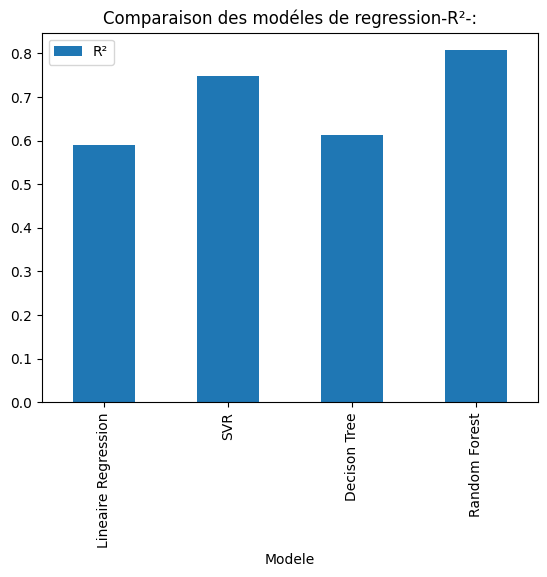

In [ ]:

#Visualsation:

import matplotlib.pyplot as plt

results_reg.plot(x="Modele",y="R²", kind="bar")

plt.title("Comparaison des modéles de regression-R²-:")
plt.show()

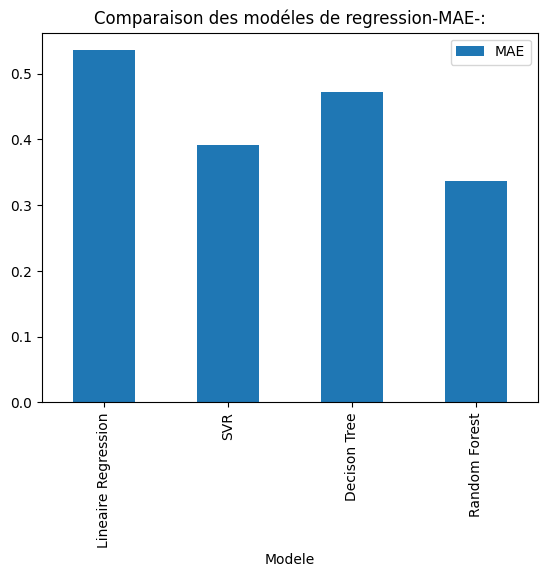

In [ ]:
#Visualsation:

import matplotlib.pyplot as plt

results_reg.plot(x="Modele",y="MAE", kind="bar")

plt.title("Comparaison des modéles de regression-MAE-:")
plt.show()

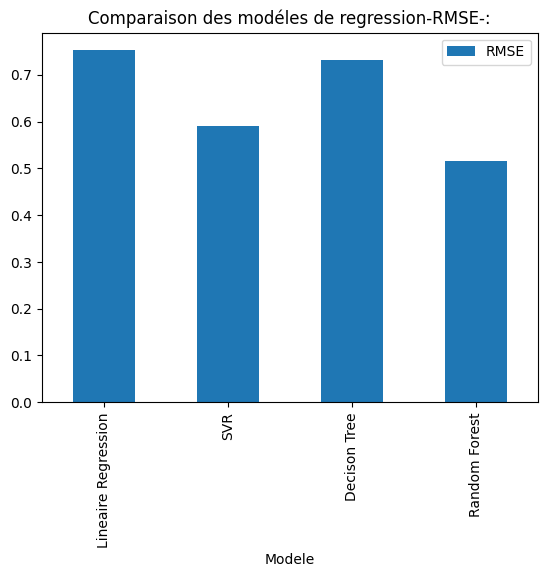

In [ ]:
#Visualsation:

import matplotlib.pyplot as plt

results_reg.plot(x="Modele",y="RMSE", kind="bar")

plt.title("Comparaison des modéles de regression-RMSE-:")
plt.show()

**MAPE-Metric supplémentaire-**

In [ ]:
from sklearn.metrics import mean_absolute_percentage_error

mape_lr= mean_absolute_percentage_error(y_test, y_pred_lr)
mape_svr= mean_absolute_percentage_error(y_test, y_pred_svr)
mape_tree= mean_absolute_percentage_error(y_test, y_pred_tree)
mape_rf= mean_absolute_percentage_error(y_test, y_pred_rf)

print("Liner Regression:",mape_lr )
print("SVR:", mape_svr)
print("Decision Tree",mape_tree)
print("Random Forest:",mape_rf)


Liner Regression: 0.3113474604113305
SVR: 0.20759693814290506
Decision Tree 0.25435485308369055
Random Forest: 0.18774942079061227


**Code bonus**

In [ ]:
from sklearn.model_selection import RandomizedSearchCV

param_grid ={
    'n_estimators':[50,100,200],
    'max_depth': [5,10,None],
    'min_samples_split':[2,5]

}

rf = RandomForestRegressor(random_state=42)
random_search = RandomizedSearchCV(
    rf, param_distributions=param_grid,
          n_iter = 5, cv=5 , random_state=42)

random_search.fit(X_train, y_train)

print("Le meilleure parametres:", random_search.best_params_)
print("Le meilleure Score:", random_search.best_score_)


Le meilleure parametres: {'n_estimators': 200, 'min_samples_split': 2, 'max_depth': 10}
Le meilleure Score: 0.7822543232249588
